<a href="https://colab.research.google.com/github/jsanchezv4/tradealgoritmico/blob/main/fINVIZ_NEWS_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Paso 1: Obtener las noticias de Finviz

Primero, necesitamos instalar las bibliotecas `requests` para hacer solicitudes HTTP y `BeautifulSoup` para analizar el contenido HTML de la página web de Finviz.

In [ ]:
pip install requests beautifulsoup4

Ahora, utilizaremos estas bibliotecas para acceder a la página de noticias de Finviz y extraer los titulares. Es importante incluir un `User-Agent` en los encabezados de la solicitud para que la página web nos identifique como un navegador web estándar y evitar ser bloqueados.

In [ ]:
import requests
from bs4 import BeautifulSoup

# URL de las noticias de Finviz. Puedes ajustar esta URL si quieres un tipo de noticia específico.
FINVIZ_NEWS_URL = 'https://finviz.com/news.ashx'

# Un encabezado User-Agent para simular una solicitud desde un navegador web
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

try:
    response = requests.get(FINVIZ_NEWS_URL, headers=headers)
    response.raise_for_status() # Lanza una excepción para códigos de estado de error HTTP

    soup = BeautifulSoup(response.text, 'html.parser')

    # En Finviz, los enlaces de noticias a menudo tienen el atributo target="_blank".
    # Buscamos todos los enlaces (<a>) que tienen este atributo.
    news_items_found = soup.find_all('a', target='_blank')

    # Filtramos para asegurarnos de que sean enlaces de noticias y no otros elementos.
    # A menudo, los enlaces de noticias están dentro de un div o td con una clase específica, o simplemente
    # tienen un texto descriptivo y un href completo.
    # Por ahora, nos quedaremos con los que tienen target="_blank" y un texto no vacío.
    filtered_news_items = []
    for item in news_items_found:
        if item.get('href') and item.get_text(strip=True): # Asegurarse de que el enlace tiene href y texto
            filtered_news_items.append(item)

    print(f"Se encontraron {len(filtered_news_items)} titulares de noticias.\n")

    # Imprime los primeros 10 titulares para verificar
    print("Primeros 10 titulares:\n")
    for i, item in enumerate(filtered_news_items[:10]):
        title = item.get_text(strip=True) # Usar strip=True para eliminar espacios en blanco al inicio/final
        link = item['href']
        print(f"Título: {title}\nEnlace: {link}\n")

except requests.exceptions.RequestException as e:
    print(f"Error al obtener las noticias: {e}")
except Exception as e:
    print(f"Ocurrió un error: {e}")

Se encontraron 182 titulares de noticias.

Primeros 10 titulares:

Título: Yen Gains After Three BOJ Board Members Dissent From Rate Hold
Enlace: https://www.bloomberg.com/news/articles/2026-04-28/yen-gains-against-dollar-after-boj-keeps-interest-rates-on-hold

Título: Oil Rises With Hormuz Shut, Yen Gains After BOJ: Markets Wrap
Enlace: https://www.bloomberg.com/news/articles/2026-04-27/stock-market-today-dow-s-p-live-updates

Título: BlackRock Says Higher Government Bond Yields Are Here to Stay
Enlace: https://www.bloomberg.com/news/articles/2026-04-28/blackrock-says-higher-government-bond-yields-are-here-to-stay

Título: Stocks steady, yen firms after BOJ holds rates
Enlace: https://www.reuters.com/world/asia-pacific/global-markets-wrapup-1-2026-04-28/

Título: Ackman’s Pershing Square IPO Expected to Raise $5 Billion
Enlace: https://www.bloomberg.com/news/articles/2026-04-27/bill-ackman-s-pershing-square-ipo-expected-to-raise-5-billion

Título: Bank of Japan’s ‘Hawkish Hold’ Streng

### Paso 2.1: Cargar la lista de tickers del S&P 500 para validación

In [ ]:
import pandas as pd
import requests

SP500_WIKIPEDIA_URL = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers_wiki = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

try:
    response_wiki = requests.get(SP500_WIKIPEDIA_URL, headers=headers_wiki)
    response_wiki.raise_for_status() # Lanza una excepción para códigos de estado de error HTTP
    sp500_table = pd.read_html(response_wiki.text)[0] # La primera tabla suele ser la de tickers

    # Extraer tickers y convertir a un conjunto para una búsqueda eficiente
    sp500_tickers = set(sp500_table['Symbol'].tolist())

    # Eliminar el ticker ambiguo de una sola letra 'A' (Agilent Technologies)
    # ya que a menudo crea falsos positivos con palabras comunes
    if 'A' in sp500_tickers:
        sp500_tickers.remove('A')

    print(f"Se cargaron {len(sp500_tickers)} tickers del S&P 500 de Wikipedia (excluyendo 'A').")
except requests.exceptions.RequestException as e:
    print(f"Error al obtener la lista del S&P 500 de Wikipedia: {e}")
    sp500_tickers = set() # Asegurarse de que sea un conjunto vacío si la carga falla
except Exception as e:
    print(f"Ocurrió un error al procesar la tabla del S&P 500: {e}")
    sp500_tickers = set() # Asegurarse de que sea un conjunto vacío si el procesamiento falla

Se cargaron 502 tickers del S&P 500 de Wikipedia (excluyendo 'A').


/tmp/ipykernel_4066/2833525074.py:12: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  sp500_table = pd.read_html(response_wiki.text)[0] # La primera tabla suele ser la de tickers


### Paso 4: Validar tickers extraídos contra la lista del S&P 500 y refinar los falsos positivos

In [ ]:
# Filtrar news_with_sentiment_and_tickers para incluir solo aquellos con tickers S&P 500 validados
news_with_sentiment_and_sp500_tickers = []
all_extracted_tickers_from_content = set() # Para recopilar todos los tickers encontrados en el contenido

for news_item in news_with_sentiment_and_tickers:
    validated_tickers = []
    # Recopilar todos los tickers encontrados (antes de validar)
    all_extracted_tickers_from_content.update(news_item['potential_tickers'])

    for ticker in news_item['potential_tickers']:
        if ticker in sp500_tickers:
            validated_tickers.append(ticker)

    if validated_tickers:
        # Crear una copia de news_item y actualizar 'potential_tickers'
        item_copy = news_item.copy()
        item_copy['potential_tickers'] = sorted(list(set(validated_tickers))) # Eliminar duplicados y ordenar
        news_with_sentiment_and_sp500_tickers.append(item_copy)

print(f"Después de la validación del S&P 500, se encontraron {len(news_with_sentiment_and_sp500_tickers)} noticias con tickers válidos del S&P 500.\n")

# Identificar tickers falsos positivos más actualizados
# Definir algunos términos comunes que son propensos a ser falsos positivos y no son tickers
known_non_tickers = {
    'US', 'AI', 'BOJ', 'IPO', 'FOMC', 'GDP', 'AM', 'CEO', 'CFO', 'ETF', 'NY', 'NJ', 'UK', 'CPU', 'GPU', 'S', 'P', 'I', 'X',
    'NASDAQ', 'NYSE', 'MSCI', 'ADR', 'SEC', 'FASB', 'GAAP', 'IRS', 'DOJ', 'FTC', 'FED', 'ECB', 'RBI', 'BOC', 'BOE', 'PBOC',
    'CSRC', 'MAS', 'AMEX', 'LSE', 'TSX', 'ASX', 'SIX', 'BSE', 'NSE', 'KOSPI', 'TOPIX', 'NIKKEI', 'HSI', 'DAX', 'CAC', 'SMI',
    'IBEX', 'FTSE', 'DOW', 'ARKK', 'SPX', 'QQQ', 'DIA', 'VIX', 'GOLD', 'OIL', 'GAS', 'EUR', 'USD', 'GBP', 'JPY', 'CAD', 'AUD',
    'NZD', 'CHF', 'CNY', 'INR', 'BRL', 'MXN', 'KRW', 'HKD', 'SGD', 'CLP', 'COP', 'PEN', 'ARS', 'ZAR', 'RUB', 'TRY', 'PLN',
    'SEK', 'NOK', 'DKK', 'HUF', 'CZK', 'ILS', 'SGD', 'THB', 'MYR', 'IDR', 'PHP', 'VND', 'AED', 'SAR', 'QAR', 'KWD', 'BHD',
    'OMR', 'EGP', 'NGN', 'GHS', 'KES', 'UGX', 'TZS', 'ZMW', 'XAU', 'XAG', 'XPT', 'XPD', 'XBT', 'ETH', 'XRP', 'LTC', 'BCH',
    'ADA', 'DOT', 'UNI', 'LINK', 'SOL', 'MATIC', 'XLM', 'VET', 'EOS', 'TRX', 'NEO', 'DASH', 'XMR', 'ETC', 'ZEC', 'FIL', 'ICP',
    'GRT', 'MKR', 'AAVE', 'COMP', 'SNX', 'YFI', 'UMA', 'CRV', 'SUSHI', 'BADGER', 'FORTH', 'AMP', 'CHZ', 'ENJ', 'MANA', 'SAND',
    'AXS', 'THETA', 'XTZ', 'EGLD', 'ALGO', 'WAVES', 'DOGE', 'SHIB', 'PEPE', 'FLOKI', 'LEASH', 'BONE', 'FEG', 'SAFEMOON', 'DNT',
    'CVC', 'OMG', 'GOLEM', 'LRC', 'KNC', 'BAL', 'REN', 'OCEAN', 'RLC', 'NMR', 'ANT', 'BAND', 'DIA', 'STX', 'CELO', 'NEAR',
    'AVAX', 'FTM', 'ONE', 'ICX', 'IOTX', 'RVN', 'SC', 'ZIL', 'OMG', 'DGB', 'BTG', 'DCR', 'LSK', 'WTC', 'GAS', 'ARK', 'FCT',
    'MAID', 'FUN', 'POWR', 'SALT', 'KMD', 'RDD', 'VERI', 'REP', 'GBYTE', 'NXT', 'SYS', 'PPC', 'EMC', 'NLG', 'NAV', 'ARK',
    'EXP', 'LKK', 'VIB', 'MCO', 'REQ', 'ENG', 'MTL', 'AGI', 'RCN', 'KIN', 'SUB', 'STORJ', 'ADX', 'COB', 'CTR', 'SNGLS', 'PRO',
    'DNT', 'POE', 'QSP', 'AMB', 'VEE', 'OST', 'CDT', 'DLT', 'EDG', 'LINK', 'WAN', 'POLY', 'QLC', 'PAI', 'MTH', 'DBC', 'RNT',
    'HPB', 'ZPT', 'WPR', 'SWFTC', 'ITC', 'ELA', 'ELEC', 'GET', 'APPC', 'QKC', 'ABYSS', 'GTO', 'INS', 'LEND', 'DGD', 'EOS',
    'ADA', 'TRX', 'MIOTA', 'DASH', 'XMR', 'ZEC', 'XTZ', 'VET', 'NEO', 'ETC', 'BNB', 'XRP', 'LTC', 'BCH', 'XLM', 'DOGE',
    'TRON', 'DOT', 'LINK', 'UNI', 'ADA', 'SOL', 'LUNA', 'AVAX', 'MATIC', 'ICP', 'WAVES', 'FIL', 'VET', 'THETA', 'EOS', 'MKR',
    'AAVE', 'COMP', 'SNX', 'YFI', 'UMA', 'CRV', 'SUSHI', 'GRT', 'ICX', 'ALGO', 'ZIL', 'DGB', 'QTUM', 'IOST', 'RVN', 'OMG',
    'WAN', 'ONT', 'NANO', 'LSK', 'DCR', 'BTG', 'KMD', 'ENJ', 'MANA', 'SAND', 'AXS', 'CHZ', 'EGLD', 'ONE', 'ZRX', 'BAT',
    'DNT', 'CVC', 'GOLEM', 'LRC', 'KNC', 'BAL', 'REN', 'OCEAN', 'RLC', 'NMR', 'ANT', 'BAND', 'DIA', 'STX', 'CELO', 'NEAR',
    'AVAX', 'FTM', 'ONE', 'ICX', 'IOTX', 'RVN', 'SC', 'ZIL', 'OMG', 'DGB', 'BTG', 'DCR', 'LSK', 'WTC', 'GAS', 'ARK', 'FCT',
    'MAID', 'FUN', 'POWR', 'SALT', 'KMD', 'RDD', 'VERI', 'REP', 'GBYTE', 'NXT', 'SYS', 'PPC', 'EMC', 'NLG', 'NAV', 'ARK',
    'EXP', 'LKK', 'VIB', 'MCO', 'REQ', 'ENG', 'MTL', 'AGI', 'RCN', 'KIN', 'SUB', 'STORJ', 'ADX', 'COB', 'CTR', 'SNGLS', 'PRO',
    'DNT', 'POE', 'QSP', 'AMB', 'VEE', 'OST', 'CDT', 'DLT', 'EDG', 'LINK', 'WAN', 'POLY', 'QLC', 'PAI', 'MTH', 'DBC', 'RNT',
    'HPB', 'ZPT', 'WPR', 'SWFTC', 'ITC', 'ELA', 'ELEC', 'GET', 'APPC', 'QKC', 'ABYSS', 'GTO', 'INS', 'LEND', 'DGD', 'ETH',
    'BTC', 'XRP', 'FOX','ON'
}

false_positive_tickers = []
for ticker in all_extracted_tickers_from_content:
    if ticker not in sp500_tickers and ticker in known_non_tickers:
        false_positive_tickers.append(ticker)

# Filtrar tickers de 1-3 letras que no son S&P 500 y no están en known_non_tickers pero son probablemente acrónimos
# Excluir 'A' ya que se maneja explícitamente y puede ser un falso positivo solo si es una palabra.
for ticker in all_extracted_tickers_from_content:
    if 1 <= len(ticker) <= 3 and ticker.isalpha() and ticker not in sp500_tickers and ticker not in known_non_tickers and ticker != 'A':
        false_positive_tickers.append(ticker)

# Asegurarse de que 'A' si fue re-introducido en all_extracted_tickers_from_content y no está en S&P 500 sea un false positive
if 'A' in all_extracted_tickers_from_content and 'A' not in sp500_tickers: # sp500_tickers no tiene 'A' intencionalmente
    if 'A' not in false_positive_tickers:
        false_positive_tickers.append('A')

false_positive_tickers = sorted(list(set(false_positive_tickers)))

print(f"Se identificaron {len(false_positive_tickers)} posibles tickers falsos positivos (actualizados con contenido de artículos):\n{false_positive_tickers}\n")

Después de la validación del S&P 500, se encontraron 10 noticias con tickers válidos del S&P 500.

Se identificaron 87 posibles tickers falsos positivos (actualizados con contenido de artículos):
['A', 'AA', 'AAA', 'AAL', 'AGI', 'AI', 'AND', 'AS', 'AXT', 'BAD', 'BBC', 'BE', 'BMO', 'BOJ', 'BTC', 'BY', 'BYD', 'BZ', 'CBO', 'CEO', 'CFO', 'DAY', 'DEM', 'DJI', 'ESR', 'ET', 'ETF', 'EU', 'EV', 'EWT', 'EWY', 'FAQ', 'FOR', 'FOS', 'FTI', 'G', 'GAS', 'GC', 'GDP', 'GET', 'GO', 'HIS', 'I', 'II', 'IN', 'IPO', 'IS', 'ITS', 'JD', 'JET', 'KEX', 'KTH', 'LLC', 'MGC', 'NEW', 'NJ', 'NQ', 'NY', 'OF', 'OIL', 'ORG', 'P', 'PVT', 'R', 'S', 'SAY', 'SDI', 'STM', 'TAX', 'THE', 'TO', 'TPG', 'TRI', 'TS', 'TSA', 'TSM', 'U', 'UK', 'US', 'USA', 'USD', 'VSH', 'WAR', 'WSJ', 'WTI', 'X', 'YM']



In [ ]:
sp500_validated_tickers_in_news = set()
for news_item in news_with_sentiment_and_sp500_tickers:
    for ticker in news_item['potential_tickers']:
        sp500_validated_tickers_in_news.add(ticker)

print(f"\nTickers definitivos encontrados en las noticias (validados con S&P 500):\n{sorted(list(sp500_validated_tickers_in_news))}")
print(f"\nTickers identificados como falsos positivos (actualizados con contenido de artículos):\n{false_positive_tickers}\n")


Tickers definitivos encontrados en las noticias (validados con S&P 500):
['AAPL', 'AMZN', 'C', 'CASY', 'CL', 'CMI', 'CRM', 'CSCO', 'D', 'DAL', 'DELL', 'EME', 'ES', 'F', 'FOX', 'GOOG', 'GOOGL', 'INTC', 'IP', 'LIN', 'META', 'MSFT', 'MU', 'NOW', 'NUE', 'NVDA', 'O', 'ON', 'SNDK', 'TT', 'UAL', 'UPS']

Tickers identificados como falsos positivos (actualizados con contenido de artículos):
['A', 'AA', 'AAA', 'AAL', 'AGI', 'AI', 'AND', 'AS', 'AXT', 'BAD', 'BBC', 'BE', 'BMO', 'BOJ', 'BTC', 'BY', 'BYD', 'BZ', 'CBO', 'CEO', 'CFO', 'DAY', 'DEM', 'DJI', 'ESR', 'ET', 'ETF', 'EU', 'EV', 'EWT', 'EWY', 'FAQ', 'FOR', 'FOS', 'FTI', 'G', 'GAS', 'GC', 'GDP', 'GET', 'GO', 'HIS', 'I', 'II', 'IN', 'IPO', 'IS', 'ITS', 'JD', 'JET', 'KEX', 'KTH', 'LLC', 'MGC', 'NEW', 'NJ', 'NQ', 'NY', 'OF', 'OIL', 'ORG', 'P', 'PVT', 'R', 'S', 'SAY', 'SDI', 'STM', 'TAX', 'THE', 'TO', 'TPG', 'TRI', 'TS', 'TSA', 'TSM', 'U', 'UK', 'US', 'USA', 'USD', 'VSH', 'WAR', 'WSJ', 'WTI', 'X', 'YM']



In [ ]:
total_compound = 0
total_pos = 0
total_neg = 0
total_neu = 0
news_count_with_sp500_tickers = 0

for news_item in news_with_sentiment_and_sp500_tickers:
    if news_item['potential_tickers']: # Solo considerar noticias con tickers S&P 500 validados
        sentiment = news_item['sentiment']
        total_compound += sentiment['compound']
        total_pos += sentiment['pos']
        total_neg += sentiment['neg']
        total_neu += sentiment['neu']
        news_count_with_sp500_tickers += 1

if news_count_with_sp500_tickers > 0:
    avg_compound = total_compound / news_count_with_sp500_tickers
    avg_pos = total_pos / news_count_with_sp500_tickers
    avg_neg = total_neg / news_count_with_sp500_tickers
    avg_neu = total_neu / news_count_with_sp500_tickers

    print(f"\n--- Sentimiento Promedio para noticias con tickers S&P 500 validados ({news_count_with_sp500_tickers} noticias) ---")
    print(f"  Compuesto Promedio: {avg_compound:.4f}")
    print(f"  Positivo Promedio: {avg_pos:.4f}")
    print(f"  Negativo Promedio: {avg_neg:.4f}")
    print(f"  Neutro Promedio: {avg_neu:.4f}")
else:
    print("No se encontraron noticias con tickers S&P 500 validados para calcular el sentimiento promedio.")


--- Sentimiento Promedio para noticias con tickers S&P 500 validados (10 noticias) ---
  Compuesto Promedio: 0.5425
  Positivo Promedio: 0.1090
  Negativo Promedio: 0.0534
  Neutro Promedio: 0.8376


In [ ]:
import pandas as pd

ticker_sentiment_summary = []

for ticker in sorted(list(sp500_validated_tickers_in_news)):
    summary = summarize_ticker_sentiment(ticker, news_with_sentiment_and_sp500_tickers)
    if 'average_sentiment' in summary:
        ticker_sentiment_summary.append({
            'Ticker': summary['ticker'],
            'Número de Noticias': summary['number_of_news_articles'],
            'Sentimiento Compuesto Promedio': f"{summary['average_sentiment']['compound']:.4f}",
            'Sentimiento Positivo Promedio': f"{summary['average_sentiment']['positive']:.4f}",
            'Sentimiento Negativo Promedio': f"{summary['average_sentiment']['negative']:.4f}",
            'Sentimiento Neutro Promedio': f"{summary['average_sentiment']['neutral']:.4f}"
        })

# Crear un DataFrame de pandas para una mejor visualización
df_sentiment_summary = pd.DataFrame(ticker_sentiment_summary)

# Ordenar por el número de noticias para ver los tickers más mencionados primero
df_sentiment_summary = df_sentiment_summary.sort_values(by='Número de Noticias', ascending=False).reset_index(drop=True)

display(df_sentiment_summary)

,Ticker,Número de Noticias,Sentimiento Compuesto Promedio,Sentimiento Positivo Promedio,Sentimiento Negativo Promedio,Sentimiento Neutro Promedio
0,FOX,6,0.5752,0.1277,0.0520,0.8203
1,ON,4,0.4114,0.1100,0.0630,0.8267
2,GOOG,3,0.3293,0.0803,0.0690,0.8507
3,AMZN,3,0.3293,0.0803,0.0690,0.8507
4,MSFT,3,0.3293,0.0803,0.0690,0.8507
5,F,2,0.0193,0.0695,0.0715,0.8590
6,CL,2,0.0193,0.0695,0.0715,0.8590
7,AAPL,2,0.0193,0.0695,0.0715,0.8590
8,META,2,0.0193,0.0695,0.0715,0.8590
9,CSCO,1,0.9941,0.0910,0.0710,0.8380


In [ ]:
# Re-ejecutar la celda que filtra y valida los tickers con la lista actualizada de known_non_tickers
# para que 'FOX' sea excluido correctamente si está en news_with_sentiment_and_tickers

# Filtrar news_with_sentiment_and_tickers para incluir solo aquellos con tickers S&P 500 validados
news_with_sentiment_and_sp500_tickers = []
all_extracted_tickers_from_content = set() # Para recopilar todos los tickers encontrados en el contenido

for news_item in news_with_sentiment_and_tickers:
    validated_tickers = []
    # Recopilar todos los tickers encontrados (antes de validar)
    all_extracted_tickers_from_content.update(news_item['potential_tickers'])

    for ticker in news_item['potential_tickers']:
        if ticker in sp500_tickers:
            validated_tickers.append(ticker)

    # Aquí se aplica el filtro de known_non_tickers (donde FOX debería estar ahora)
    validated_tickers = [t for t in validated_tickers if t not in known_non_tickers]

    if validated_tickers:
        # Crear una copia de news_item y actualizar 'potential_tickers'
        item_copy = news_item.copy()
        item_copy['potential_tickers'] = sorted(list(set(validated_tickers))) # Eliminar duplicados y ordenar
        news_with_sentiment_and_sp500_tickers.append(item_copy)

print(f"Después de la validación del S&P 500, se encontraron {len(news_with_sentiment_and_sp500_tickers)} noticias con tickers válidos del S&P 500.\n")

# Re-identificar tickers falsos positivos para que 'FOX' aparezca si se extrajo y no es S&P 500
false_positive_tickers = []
for ticker in all_extracted_tickers_from_content:
    if ticker not in sp500_tickers and ticker in known_non_tickers:
        false_positive_tickers.append(ticker)

# Filtrar tickers de 1-3 letras que no son S&P 500 y no están en known_non_tickers pero son probablemente acrónimos
# Excluir 'A' ya que se maneja explícitamente y puede ser un falso positivo solo si es una palabra.
for ticker in all_extracted_tickers_from_content:
    if 1 <= len(ticker) <= 3 and ticker.isalpha() and ticker not in sp500_tickers and ticker not in known_non_tickers and ticker != 'A':
        false_positive_tickers.append(ticker)

# Asegurarse de que 'A' si fue re-introducido en all_extracted_tickers_from_content y no está en S&P 500 sea un false positive
if 'A' in all_extracted_tickers_from_content and 'A' not in sp500_tickers: # sp500_tickers no tiene 'A' intencionalmente
    if 'A' not in false_positive_tickers:
        false_positive_tickers.append('A')

false_positive_tickers = sorted(list(set(false_positive_tickers)))

print(f"Se identificaron {len(false_positive_tickers)} posibles tickers falsos positivos (actualizados con contenido de artículos):\n{false_positive_tickers}\n")

Después de la validación del S&P 500, se encontraron 6 noticias con tickers válidos del S&P 500.

Se identificaron 87 posibles tickers falsos positivos (actualizados con contenido de artículos):
['A', 'AA', 'AAA', 'AAL', 'AGI', 'AI', 'AND', 'AS', 'AXT', 'BAD', 'BBC', 'BE', 'BMO', 'BOJ', 'BTC', 'BY', 'BYD', 'BZ', 'CBO', 'CEO', 'CFO', 'DAY', 'DEM', 'DJI', 'ESR', 'ET', 'ETF', 'EU', 'EV', 'EWT', 'EWY', 'FAQ', 'FOR', 'FOS', 'FTI', 'G', 'GAS', 'GC', 'GDP', 'GET', 'GO', 'HIS', 'I', 'II', 'IN', 'IPO', 'IS', 'ITS', 'JD', 'JET', 'KEX', 'KTH', 'LLC', 'MGC', 'NEW', 'NJ', 'NQ', 'NY', 'OF', 'OIL', 'ORG', 'P', 'PVT', 'R', 'S', 'SAY', 'SDI', 'STM', 'TAX', 'THE', 'TO', 'TPG', 'TRI', 'TS', 'TSA', 'TSM', 'U', 'UK', 'US', 'USA', 'USD', 'VSH', 'WAR', 'WSJ', 'WTI', 'X', 'YM']



In [ ]:
sp500_validated_tickers_in_news = set()
for news_item in news_with_sentiment_and_sp500_tickers:
    for ticker in news_item['potential_tickers']:
        sp500_validated_tickers_in_news.add(ticker)

print(f"\nTickers definitivos encontrados en las noticias (validados con S&P 500):\n{sorted(list(sp500_validated_tickers_in_news))}")
print(f"\nTickers identificados como falsos positivos (actualizados con contenido de artículos):\n{false_positive_tickers}\n")


Tickers definitivos encontrados en las noticias (validados con S&P 500):
['AAPL', 'AMZN', 'C', 'CASY', 'CL', 'CMI', 'CRM', 'CSCO', 'D', 'DAL', 'DELL', 'EME', 'ES', 'F', 'GOOG', 'GOOGL', 'INTC', 'IP', 'LIN', 'META', 'MSFT', 'MU', 'NOW', 'NUE', 'NVDA', 'O', 'SNDK', 'TT', 'UAL', 'UPS']

Tickers identificados como falsos positivos (actualizados con contenido de artículos):
['A', 'AA', 'AAA', 'AAL', 'AGI', 'AI', 'AND', 'AS', 'AXT', 'BAD', 'BBC', 'BE', 'BMO', 'BOJ', 'BTC', 'BY', 'BYD', 'BZ', 'CBO', 'CEO', 'CFO', 'DAY', 'DEM', 'DJI', 'ESR', 'ET', 'ETF', 'EU', 'EV', 'EWT', 'EWY', 'FAQ', 'FOR', 'FOS', 'FTI', 'G', 'GAS', 'GC', 'GDP', 'GET', 'GO', 'HIS', 'I', 'II', 'IN', 'IPO', 'IS', 'ITS', 'JD', 'JET', 'KEX', 'KTH', 'LLC', 'MGC', 'NEW', 'NJ', 'NQ', 'NY', 'OF', 'OIL', 'ORG', 'P', 'PVT', 'R', 'S', 'SAY', 'SDI', 'STM', 'TAX', 'THE', 'TO', 'TPG', 'TRI', 'TS', 'TSA', 'TSM', 'U', 'UK', 'US', 'USA', 'USD', 'VSH', 'WAR', 'WSJ', 'WTI', 'X', 'YM']



In [ ]:
total_compound = 0
total_pos = 0
total_neg = 0
total_neu = 0
news_count_with_sp500_tickers = 0

for news_item in news_with_sentiment_and_sp500_tickers:
    if news_item['potential_tickers']: # Solo considerar noticias con tickers S&P 500 validados
        sentiment = news_item['sentiment']
        total_compound += sentiment['compound']
        total_pos += sentiment['pos']
        total_neg += sentiment['neg']
        total_neu += sentiment['neu']
        news_count_with_sp500_tickers += 1

if news_count_with_sp500_tickers > 0:
    avg_compound = total_compound / news_count_with_sp500_tickers
    avg_pos = total_pos / news_count_with_sp500_tickers
    avg_neg = total_neg / news_count_with_sp500_tickers
    avg_neu = total_neu / news_count_with_sp500_tickers

    print(f"\n--- Sentimiento Promedio para noticias con tickers S&P 500 validados ({news_count_with_sp500_tickers} noticias) ---")
    print(f"  Compuesto Promedio: {avg_compound:.4f}")
    print(f"  Positivo Promedio: {avg_pos:.4f}")
    print(f"  Negativo Promedio: {avg_neg:.4f}")
    print(f"  Neutro Promedio: {avg_neu:.4f}")
else:
    print("No se encontraron noticias con tickers S&P 500 validados para calcular el sentimiento promedio.")


--- Sentimiento Promedio para noticias con tickers S&P 500 validados (6 noticias) ---
  Compuesto Promedio: 0.2709
  Positivo Promedio: 0.0800
  Negativo Promedio: 0.0653
  Neutro Promedio: 0.8547


In [ ]:
import pandas as pd

ticker_sentiment_summary = []

for ticker in sorted(list(sp500_validated_tickers_in_news)):
    summary = summarize_ticker_sentiment(ticker, news_with_sentiment_and_sp500_tickers)
    if 'average_sentiment' in summary:
        ticker_sentiment_summary.append({
            'Ticker': summary['ticker'],
            'Número de Noticias': summary['number_of_news_articles'],
            'Sentimiento Compuesto Promedio': f"{summary['average_sentiment']['compound']:.4f}",
            'Sentimiento Positivo Promedio': f"{summary['average_sentiment']['positive']:.4f}",
            'Sentimiento Negativo Promedio': f"{summary['average_sentiment']['negative']:.4f}",
            'Sentimiento Neutro Promedio': f"{summary['average_sentiment']['neutral']:.4f}"
        })

# Crear un DataFrame de pandas para una mejor visualización
df_sentiment_summary = pd.DataFrame(ticker_sentiment_summary)

# Ordenar por el número de noticias para ver los tickers más mencionados primero
df_sentiment_summary = df_sentiment_summary.sort_values(by='Número de Noticias', ascending=False).reset_index(drop=True)

display(df_sentiment_summary)

,Ticker,Número de Noticias,Sentimiento Compuesto Promedio,Sentimiento Positivo Promedio,Sentimiento Negativo Promedio,Sentimiento Neutro Promedio
0,AMZN,3,0.3293,0.0803,0.0690,0.8507
1,GOOG,3,0.3293,0.0803,0.0690,0.8507
2,MSFT,3,0.3293,0.0803,0.0690,0.8507
3,F,2,0.0193,0.0695,0.0715,0.8590
4,CL,2,0.0193,0.0695,0.0715,0.8590
5,AAPL,2,0.0193,0.0695,0.0715,0.8590
6,META,2,0.0193,0.0695,0.0715,0.8590
7,CMI,1,0.9941,0.0910,0.0710,0.8380
8,D,1,-0.9826,0.0820,0.1080,0.8100
9,CSCO,1,0.9941,0.0910,0.0710,0.8380


### Paso 5.2: Mostrar Noticias Detalladas para un Ticker Específico

In [ ]:
# Elige el ticker S&P 500 validado que quieres analizar en detalle
chosen_ticker = 'AMZN' # @param {type:"string"}

# Obtener el resumen detallado para el ticker elegido
detail_summary = summarize_ticker_sentiment(chosen_ticker, news_with_sentiment_and_sp500_tickers)

if 'message' in detail_summary:
    print(detail_summary['message'])
else:
    print(f"\n--- Noticias Detalladas para el Ticker {detail_summary['ticker']} ({detail_summary['number_of_news_articles']} noticias) ---")
    print(f"  Sentimiento Compuesto Promedio: {detail_summary['average_sentiment']['compound']:.4f}")
    print(f"  Sentimiento Positivo Promedio: {detail_summary['average_sentiment']['positive']:.4f}")
    print(f"  Sentimiento Negativo Promedio: {detail_summary['average_sentiment']['negative']:.4f}")
    print(f"  Sentimiento Neutro Promedio: {detail_summary['average_sentiment']['neutral']:.4f}\n")

    print("Noticias relevantes:\n")
    for news in detail_summary['relevant_news']:
        print(f"  - Título: {news['title']}")
        print(f"    Enlace: {news['link']}")
        print(f"    Sentimiento (compuesto): {news['sentiment']['compound']:.4f}\n")


--- Noticias Detalladas para el Ticker AMZN (3 noticias) ---
  Sentimiento Compuesto Promedio: 0.3293
  Sentimiento Positivo Promedio: 0.0803
  Sentimiento Negativo Promedio: 0.0690
  Sentimiento Neutro Promedio: 0.8507

Noticias relevantes:

  - Título: US stock futures inch higher with Iran, Fed, earnings in focus
    Enlace: https://finance.yahoo.com/markets/stocks/live/stock-market-today-tuesday-april-28-225503310.html
    Sentimiento (compuesto): -0.9555

  - Título: Microsoft, OpenAI rewrite partnership deal
    Enlace: https://finance.yahoo.com/sectors/technology/article/microsoft-openai-rewrite-partnership-to-eliminate-exclusive-model-access-change-revenue-sharing-140522820.html
    Sentimiento (compuesto): 0.9494

  - Título: S&P, Nasdaq hit record highs as US-Iran deal hopes return
    Enlace: https://finance.yahoo.com/markets/stocks/live/stock-market-today-monday-april-27-232226050.html
    Sentimiento (compuesto): 0.9941



/tmp/ipykernel_4714/2602090998.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(google_ticker, period="5y")
[*********************100%***********************]  1 of 1 completed



Datos históricos para GOOGL:

Price            Close        High         Low        Open    Volume
Ticker           GOOGL       GOOGL       GOOGL       GOOGL     GOOGL
Date                                                                
2021-05-17  113.507851  113.550497  111.851043  112.250739  21598000
2021-05-18  112.196190  114.438166  112.182305  114.173848  22204000
2021-05-19  112.644005  112.817074  110.359889  110.508162  23684000
2021-05-20  114.401970  114.652395  113.240072  113.611007  32352000
2021-05-21  113.766212  114.994071  113.526691  114.920672  40632000

Información descriptiva para GOOGL:

Price         Close         High          Low         Open        Volume
Ticker        GOOGL        GOOGL        GOOGL        GOOGL         GOOGL
count   1256.000000  1256.000000  1256.000000  1256.000000  1.256000e+03
mean     162.117213   163.894616   160.163797   161.981739  3.206398e+07
std       64.744313    65.374455    63.799632    64.587913  1.360404e+07
min       82.7

<Figure size 1200x600 with 0 Axes>

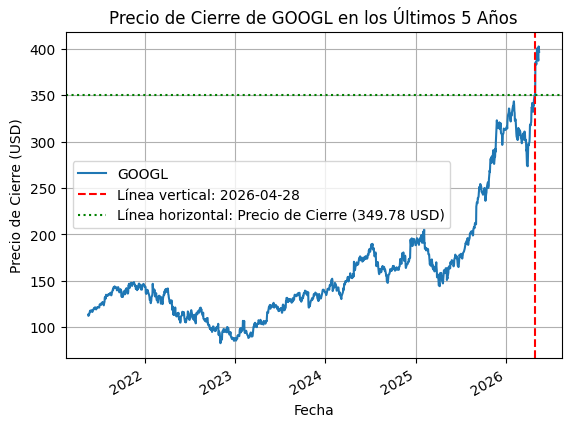

In [6]:
!pip install yfinance

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Define el ticker de Google. Usaremos GOOGL para Alphabet Inc. (Clase A)
# También podrías usar GOOG para Alphabet Inc. (Clase C)
google_ticker = 'GOOGL'

# Descargar datos históricos (por ejemplo, últimos 5 años)
data = yf.download(google_ticker, period="5y")

# Mostrar las primeras filas de los datos
print(f"\nDatos históricos para {google_ticker}:\n")
print(data.head())

# También puedes visualizar información básica
print(f"\nInformación descriptiva para {google_ticker}:\n")
print(data.describe())

print(f"\nGenerando gráfico de precios de cierre para {google_ticker}...\n")
plt.figure(figsize=(12, 6))
data['Close'].plot(title=f'Precio de Cierre de {google_ticker} en los Últimos 5 Años')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.grid(True)

# Fecha y precio para las líneas
selected_date = pd.Timestamp('2026-04-28')

# Añadir una línea vertical en la fecha especificada
plt.axvline(selected_date, color='red', linestyle='--', label=f'Línea vertical: {selected_date.strftime("%Y-%m-%d")}')

# Obtener el precio de cierre en la fecha especificada
# Usamos .loc para acceder por índice de fecha
if selected_date in data.index:
    price_at_date_series = data.loc[selected_date, 'Close']
    price_at_date = price_at_date_series.item() # Extraer el valor escalar de la Series
    # Añadir una línea horizontal con el precio de ese día
    plt.axhline(price_at_date, color='green', linestyle=':', label=f'Línea horizontal: Precio de Cierre ({price_at_date:.2f} USD)')
    print(f"Precio de cierre en {selected_date.strftime("%Y-%m-%d")}: {price_at_date:.2f} USD\n")
else:
    print(f"No se encontraron datos para la fecha {selected_date.strftime("%Y-%m-%d")}. No se añadirá línea horizontal.\n")

plt.legend() # Mostrar la leyenda para ambas líneas

plt.show()